# Decision Trees using Breast Cancer dataset



In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [123]:
data = pd.read_csv("data.csv")
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [124]:
data.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [125]:
data.drop(['Unnamed: 32','id'], axis=1, inplace=True)

In [126]:
M = data[data.diagnosis == 'M']
B = data[data.diagnosis == 'B']

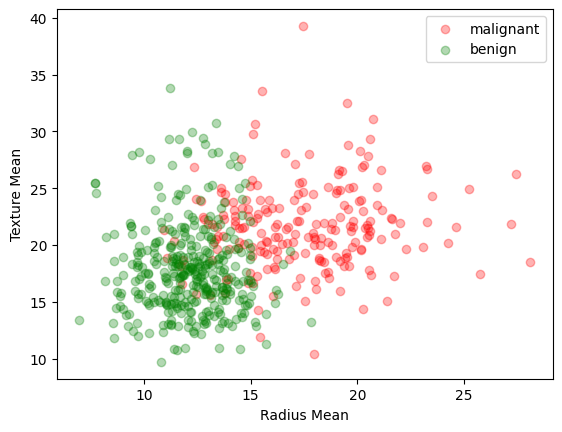

In [127]:
# Scatter Plot
# Create a scatter plot to visualize the relationship between "radius_mean" and "texture_mean."
plt.scatter(M.radius_mean, M.texture_mean, color="red", label="malignant", alpha=0.3)
plt.scatter(B.radius_mean, B.texture_mean, color="green", label="benign", alpha=0.3)
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.legend()
plt.show()

In [128]:
data["diagnosis"] = data["diagnosis"].map({"M": 1, "B": 0})

# Target variable
y = data["diagnosis"]

# Features
x_data = data.drop("diagnosis", axis=1)

In [129]:
# Normalize data between 0 and 1
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())

In [130]:
# Train-Test Split
# Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

# Decision Tree Classifier
# Create a Decision Tree Classifier and fit it to the training data.
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

# Calculate and print the accuracy score.
print("Accuracy Score:", dt.score(x_test, y_test))

Accuracy Score: 0.9069767441860465


In [131]:
dt.predict(x_test)

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1])

# Decision Tree using titanic Dataset

In [147]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


In [148]:
# 1. Dataset ko load karna (Seaborn se direct)
df = sns.load_dataset('titanic')

In [149]:
# 2. Data Cleaning & Feature Selection
# Duplicate aur repetitive columns ko drop kar rahe hain taake model confuse na ho
# 'alive' bilkul 'survived' jaisa hai, isliye isay hatana lazmi hai
columns_to_drop = ['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
df.drop(columns=columns_to_drop, inplace=True)

In [150]:
# 3. Missing Values (Khali data) ko fill karna
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

/tmp/ipykernel_745/3949647023.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_745/3949647023.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [151]:
# 4. Text Data ko Numbers mein convert karna (Encoding)
# Sex (male/female) ko 0 aur 1 mein badalna
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

In [152]:
# Embarked column ko numerical (dummy variables) mein convert karna
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [153]:

# 5. X (Features) aur y (Target) ko alag karna
X = df.drop(columns=['survived'])
y = df['survived']

In [154]:
# 6. Train aur Test sets mein split karna (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [155]:
# 7. Decision Tree Classifier ko Train karna
# max_depth=3 rakha hai taake tree overfit na ho aur samajh aane ke qabil ho
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [156]:
# 8. Model ki Accuracy check karna
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [157]:
print("--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

--- Model Evaluation ---
Accuracy Score: 0.7989

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



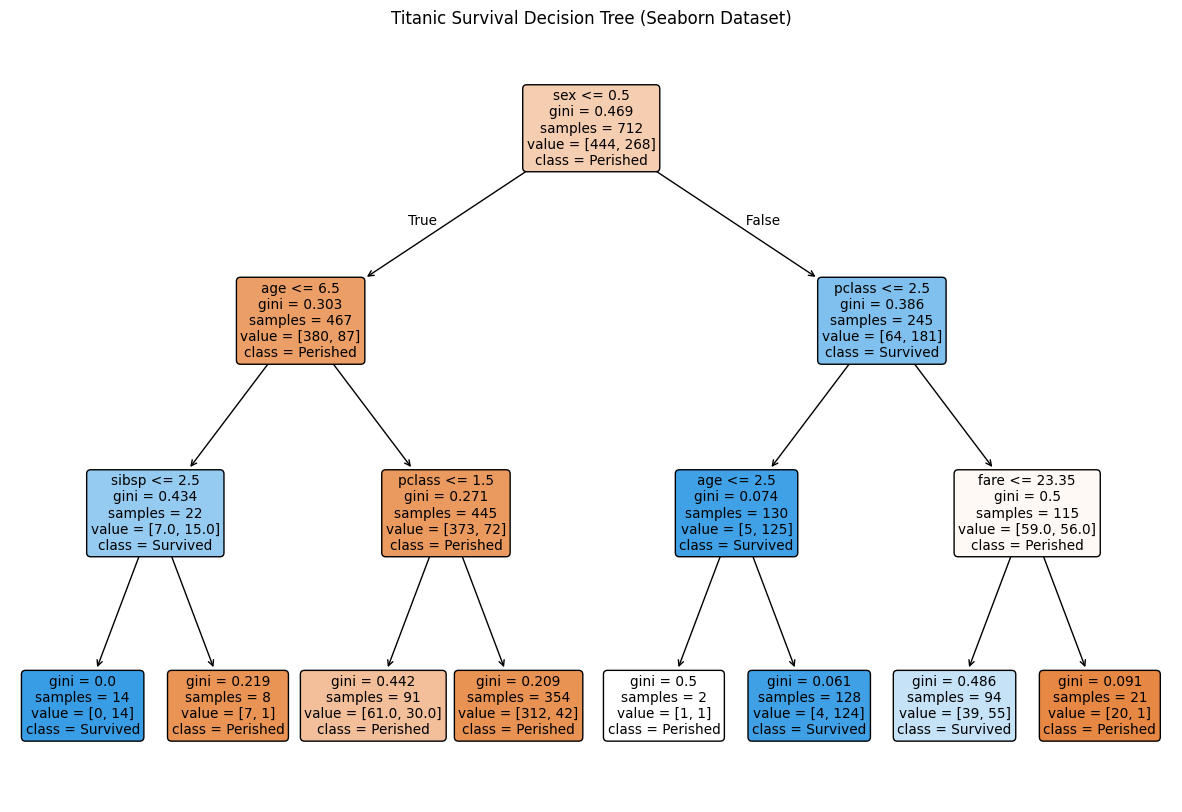

In [158]:
# 9. Decision Tree ka Graph banana
plt.figure(figsize=(15, 10))
plot_tree(clf, feature_names=X.columns, class_names=['Perished', 'Survived'], filled=True, rounded=True)
plt.title("Titanic Survival Decision Tree (Seaborn Dataset)")
plt.show()















# Decision Trees using wine dataset



In [177]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [178]:
# Load data
df = pd.read_csv('/content/WineQT.csv')

In [179]:
# Features and target
X = df.drop('quality', axis=1)
y = df['quality']

In [180]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [186]:
# Create model
model = DecisionTreeClassifier(random_state=42)

In [187]:
# Train model
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [188]:
# Prediction
y_pred = model.predict(X_test)

In [189]:

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5918367346938775


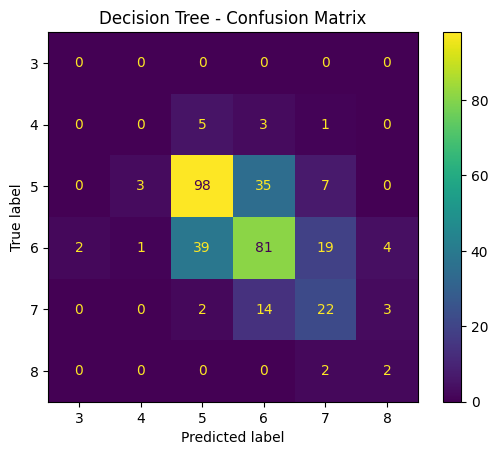

In [190]:
# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()



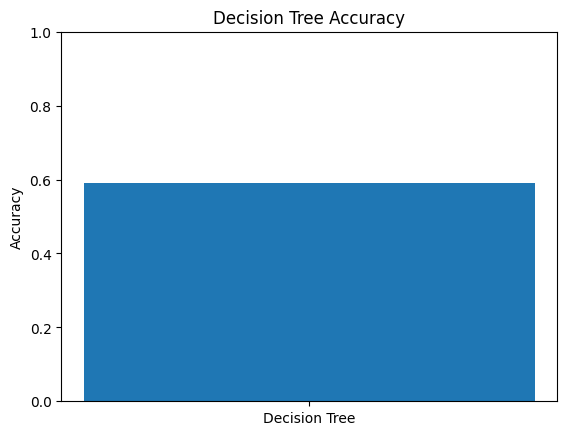

In [165]:
# 9. Accuracy Graph
plt.bar(["Decision Tree"], [accuracy])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy")
plt.show()